In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load Dataset
df = pd.read_csv("Titanic.csv")

In [3]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
print(df.tail())

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [5]:
print("Shape:", df.shape)
print(df.columns)
print(df.info())
print(df.describe())

Shape: (891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \

In [6]:
# Missing Values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


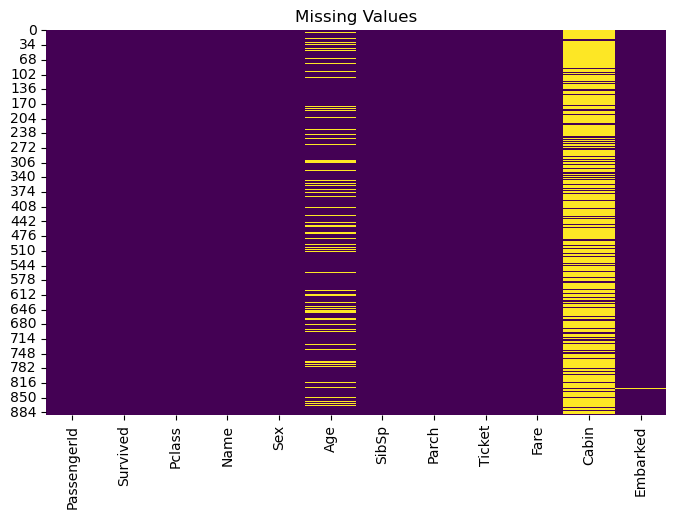

In [7]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.show()

In [8]:
# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [9]:
# Duplicate Values
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


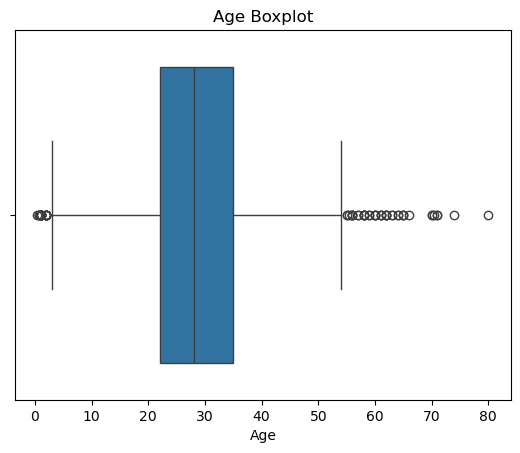

In [11]:
# Outlier Detection
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.show()

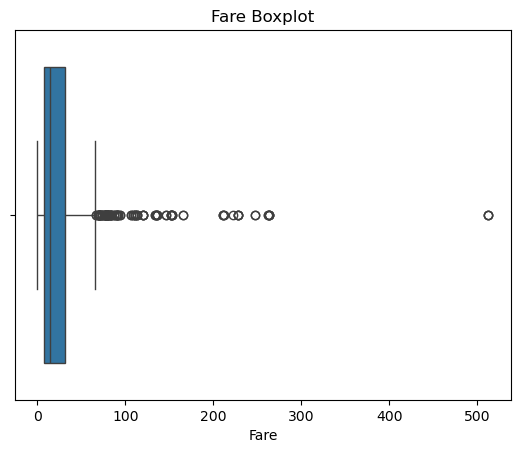

In [12]:
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

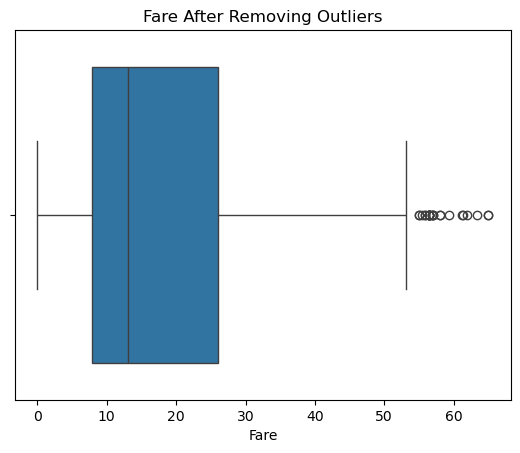

In [13]:
# Remove Fare Outliers
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

sns.boxplot(x=df["Fare"])
plt.title("Fare After Removing Outliers")
plt.show()

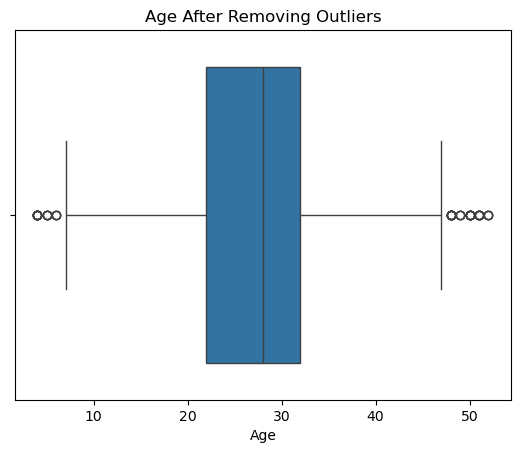

In [14]:
# Remove Age Outliers
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Age"] >= lower) & (df["Age"] <= upper)]

sns.boxplot(x=df["Age"])
plt.title("Age After Removing Outliers")
plt.show()

In [15]:
# Encoding

df["Sex"] = df["Sex"].replace("male", 0)
df["Sex"] = df["Sex"].replace("female", 1)

print(df.head())

print(df["Embarked"].unique())

   PassengerId  Survived  Pclass  \
0            1         0       3   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   

                                           Name  Sex   Age  SibSp  Parch  \
0                       Braund, Mr. Owen Harris    0  22.0      1      0   
2                        Heikkinen, Miss. Laina    1  26.0      0      0   
3  Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                      Allen, Mr. William Henry    0  35.0      0      0   
5                              Moran, Mr. James    0  28.0      0      0   

             Ticket     Fare Cabin Embarked  
0         A/5 21171   7.2500   NaN        S  
2  STON/O2. 3101282   7.9250   NaN        S  
3            113803  53.1000  C123        S  
4            373450   8.0500   NaN        S  
5            330877   8.4583   NaN        Q  
['S' 'Q' 'C']


C:\Users\niraj\AppData\Local\Temp\ipykernel_30700\2031088115.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Sex"] = df["Sex"].replace("female", 1)


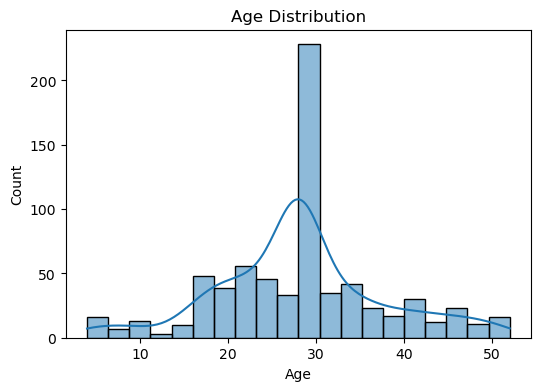

In [16]:
# Univariate Analysis
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

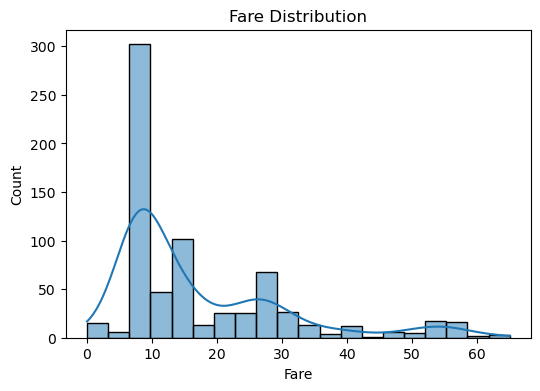

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df["Fare"], bins=20, kde=True)
plt.title("Fare Distribution")
plt.show()

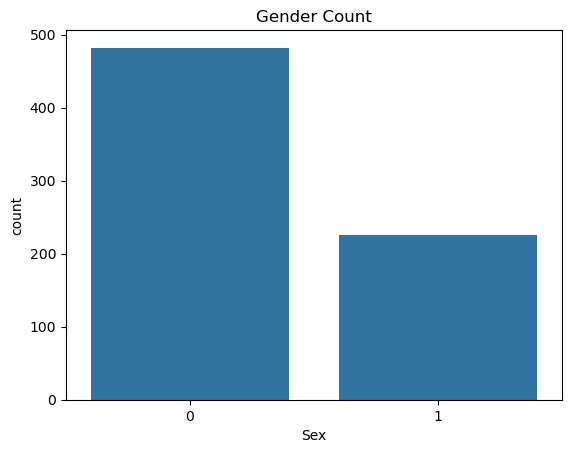

In [18]:
sns.countplot(x="Sex", data=df)
plt.title("Gender Count")
plt.show()

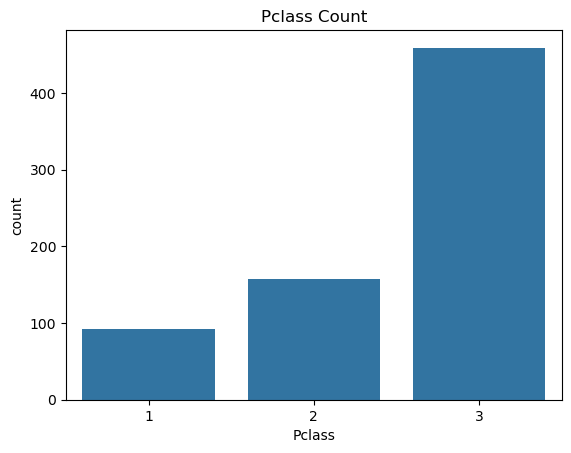

In [19]:
sns.countplot(x="Pclass", data=df)
plt.title("Pclass Count")
plt.show()

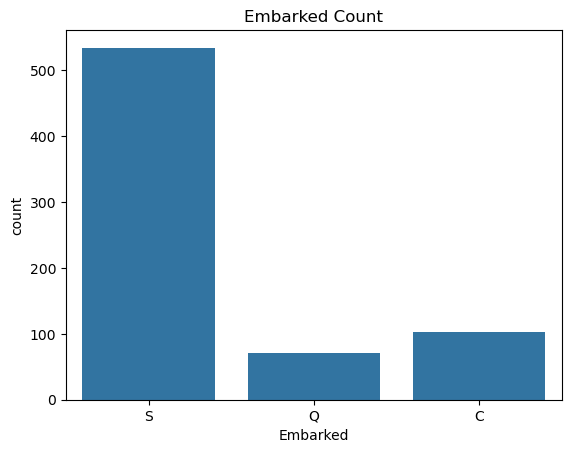

In [20]:
sns.countplot(x="Embarked", data=df)
plt.title("Embarked Count")
plt.show()

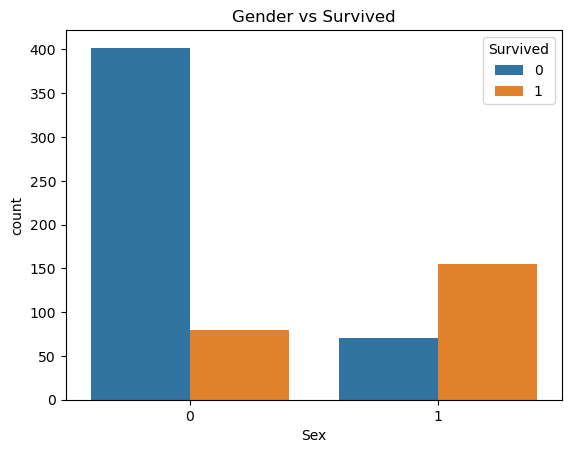

In [21]:
# Bivariate Analysis
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Gender vs Survived")
plt.show()

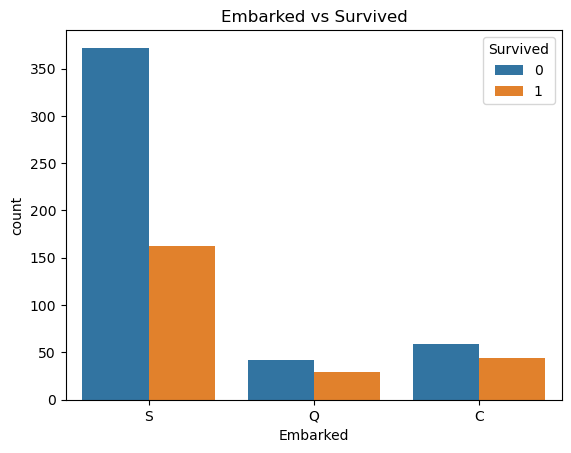

In [22]:
sns.countplot(x="Embarked", hue="Survived", data=df)
plt.title("Embarked vs Survived")
plt.show()

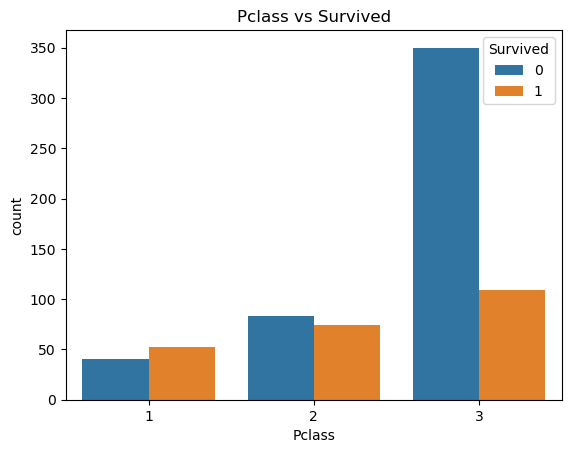

In [23]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Pclass vs Survived")
plt.show()

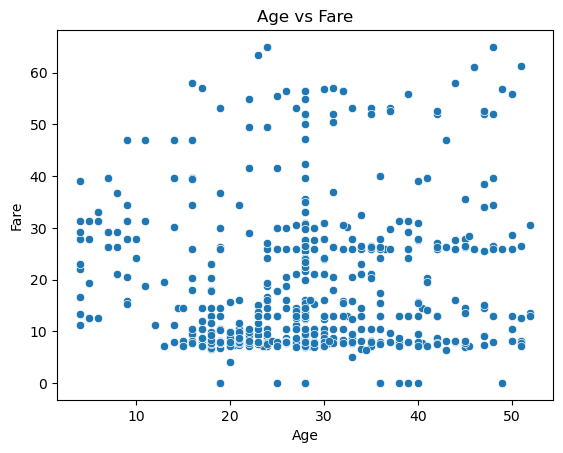

In [24]:
sns.scatterplot(x="Age", y="Fare", data=df)
plt.title("Age vs Fare")
plt.show()


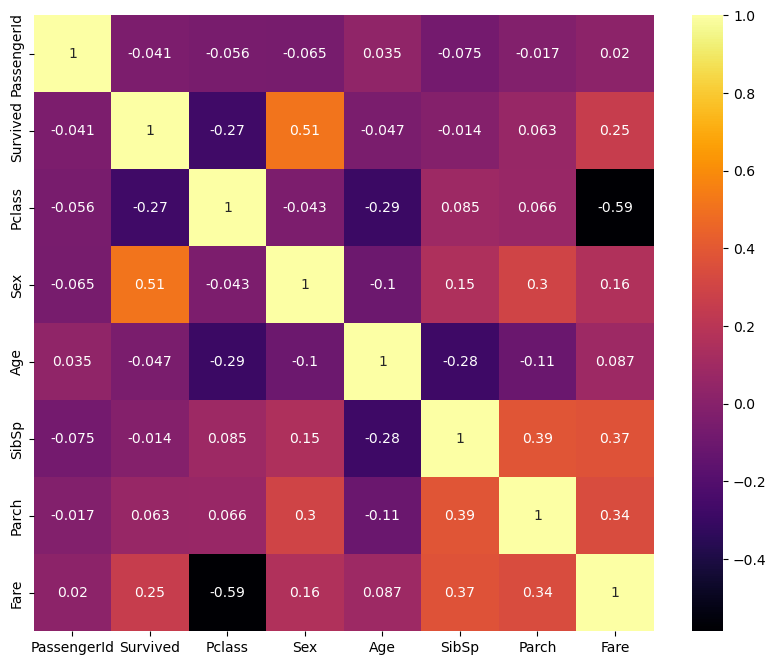

In [25]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="inferno"
)

plt.show()

In [26]:
# Feature Scaling

X = df.drop("Survived", axis=1)
Y = df["Survived"]

X = X.drop(["PassengerId", "Name", "Ticket"], axis=1)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[["Age", "Fare"]] = scaler.fit_transform(X[["Age", "Fare"]])

print(X.head())

   Pclass  Sex       Age  SibSp  Parch      Fare Cabin Embarked
0       3    0 -0.637115      1      0 -0.737419   NaN        S
2       3    1 -0.216039      0      0 -0.687065   NaN        S
3       1    1  0.731381      1      0  2.682952  C123        S
4       3    0  0.731381      0      0 -0.677740   NaN        S
5       3    0 -0.005501      0      0 -0.647281   NaN        Q


In [27]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

print(X_train.head())

Training Data: (566, 8)
Testing Data : (142, 8)
     Pclass  Sex       Age  SibSp  Parch      Fare Cabin Embarked
666       2    0 -0.321308      0      0 -0.308474   NaN        S
32        3    1 -0.005501      0      0 -0.700120   NaN        Q
611       3    0 -0.005501      0      0 -0.752339   NaN        S
405       2    0  0.626112      1      0  0.288319   NaN        S
300       3    1 -0.005501      0      0 -0.700120   NaN        Q
